# SNN: Spiking Neural Networks

The objective of this notebook is to provide a comprehensive overview of **Spiking Neural Networks (SNNs)**. This content is built upon several key existing works, such as:

* [neuro4ml](https://neuro4ml.github.io/)
* [snntorch](https://snntorch.readthedocs.io/en/latest/index.html)

While these notebooks provide a solid foundation for understanding SNNs from a software perspective, they offer limited insight into the underlying **hardware implementations**. Consequently, this notebook focuses on the **electronic components** and architectural design specific to neuromorphic computing.

The initial section of this notebook handles the importation of required libraries and establishes the graphical formatting parameters to ensure consistent data visualization throughout the analysis.

## Import and Formatting

The goal of this section is to import all the necessary files and libraries required for the subsequent data analysis.  
It also includes setting up the formatting parameters for the plots and visualizations.

### Import

In [1]:
# ----  Standard import
import matplotlib.pyplot as plt
import numpy as np

# ---- Animation import
try : 
    import ipywidgets as widgets
except ImportError:
    widgets = None
    print("Attention l'importation de ipywidgets n'est pas possible")

import os
os.environ["NGSPICE_LIBRARY_PATH"] = r"C:\Users\sacha\anaconda3\envs\electronique\Library\bin\ngspice.dll"

# ----- Spice import
from PySpice.Spice.Netlist import Circuit, SubCircuit
from PySpice.Unit import *


import brian2
brian2.prefs.codegen.target = 'numpy'

Attention l'importation de ipywidgets n'est pas possible


### Formatting

Adjusting Plotly chart settings for clarity and consistency.

In [2]:
# ----  Formatting charts
%matplotlib inline
from IPython.core.pylabtools import figsize
import matplotlib as mpl
mpl.rcParams['lines.linewidth'] = 2.0
mpl.rcParams['axes.edgecolor']  = "#bcbcbc"
mpl.rcParams['patch.linewidth'] = 0.5
mpl.rcParams['legend.fancybox'] = True
mpl.rcParams['axes.facecolor']  = "#eeeeee"
mpl.rcParams['axes.labelsize']  = "large"
mpl.rcParams['axes.grid']       = True
mpl.rcParams['grid.linestyle']  = "--"
mpl.rcParams['patch.edgecolor'] = "#eeeeee"
mpl.rcParams['axes.titlesize']  = "x-large"

## ANN Problem Statement

Neural networks are relatively **long-standing** techniques, yet they have only been effectively implemented **recently**. This is because the necessary computing power was previously unavailable. The fundamental building block of neural networks is the **perceptron**, a component that performs two main operations:

1. **A weighted sum** of the inputs and their respective weights. This operation can be modeled as follows:

$$y_{linear} = \sum_{i=0}^{n} x_i \cdot w_i$$



*Where $n$ corresponds to the number of inputs, $x_i$ represents the input values, and $w_i$ represents the weights associated with each input. During the learning phase, the objective is to determine the optimal weights.*
2. **A non-linear activation function**, such as **ReLU** or **Sigmoid**, which is applied to the result of the sum.

The classic model of a perceptron is summarized in the following [](#neurones_classique_model_SNN):

```{figure} ./images/neurones.svg
:name: neurones_classique_model_SNN
:align: center
:width: 400px

Classic model of a perceptron
```

**Hardware Challenges:**
While this model is straightforward to simulate in digital electronics, its efficient implementation poses significant challenges. In current microcontrollers (based on **Von Neumann** or **Harvard** architectures (see [](#von_neumann_harvard))), there is a persistent **bottleneck** between the memory and the processing unit (CPU). The processor often spends the majority of its time waiting for data (weights and inputs) to be fetched from memory, which limits processing speed—even with various levels of cache—and increases energy consumption. Furthermore, while summation is easy to achieve in electronics, implementing non-linear functions and ensuring precise weight storage remain major hurdles for purely analog approaches.


```{figure} ./images/von_neumann_harvard.svg
:name: von_neumann_harvard
:align: center
:width: 400px

Von Neumann Machine Vs Harvard Machine
```

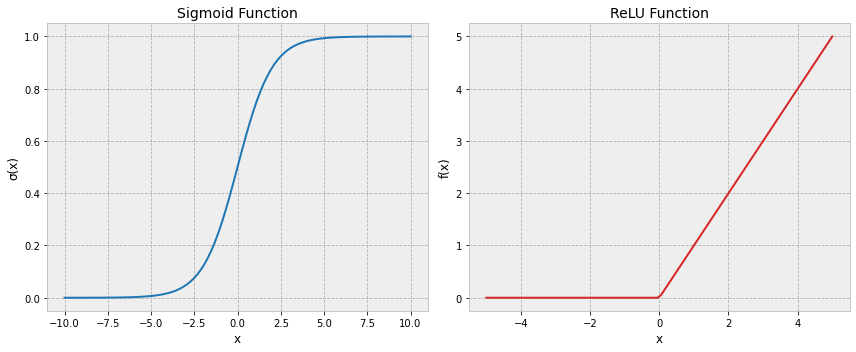

In [3]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    """Compute the sigmoid activation function."""
    return 1 / (1 + np.exp(-x))

def relu(x: np.ndarray) -> np.ndarray:
    """Compute the Rectified Linear Unit (ReLU) activation function."""
    return np.maximum(0, x)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Sigmoid Plot ---
x_sig = np.linspace(-10, 10, 100)
ax1.plot(x_sig, sigmoid(x_sig), color='tab:blue', linewidth=2)
ax1.set_title("Sigmoid Function", fontsize=14)
ax1.set_xlabel("x")
ax1.set_ylabel("σ(x)")

# --- ReLU Plot ---
x_relu = np.linspace(-5, 5, 100)
ax2.plot(x_relu, relu(x_relu), color='tab:red', linewidth=2)
ax2.set_title("ReLU Function", fontsize=14)
ax2.set_xlabel("x")
ax2.set_ylabel("f(x)")

plt.tight_layout()
plt.show()

Before we begin, please note that our focus here will be strictly on the **mathematical and electronic** perspectives. While the biological aspect is highly compelling, you can refer to these [notebooks](https://neuro4ml.github.io/) for a deeper dive into the neuroscience.

The most basic building block we can create is the **IF (Integrate and Fire)** neuron.

## The Integrate and Fire (IF) Neuron - Simulmtion

The IF neuron model is based on the accumulation (integration) of input signals over time. Unlike traditional artificial neurons that output continuous values, an IF neuron only transmits a signal (a "spike") once its internal membrane potential reaches a specific threshold.

In the following section, we will examine the inner workings of an integrator:

In [4]:
# 1. Simulation Parameters
# ------------------------
b_ms = brian2.ms                  # Time base (milliseconds)
duration = 50 * b_ms              # Total simulation duration
n_spikes = 5                      # Number of spikes to generate
inter_spike_interval = 10 * b_ms  # Interval between spikes

# Define spike timings
spike_times = brian2.arange(1, n_spikes + 1) * inter_spike_interval

# Neuron differential equation (Passive IF Model)
# dv/dt = 0 implies that v remains constant between synaptic events.
model_eqs = 'dv/dt = 0/second : 1'    # Neuron differential equation

# 2. Defining Groups (Input & Output)
# -----------------------------------
# Spike Generator: emits spikes at the predefined spike_times
input_group = brian2.SpikeGeneratorGroup(1, [0]*n_spikes, spike_times)

# Output Neuron Group
output_group = brian2.NeuronGroup(
    1, 
    model_eqs, 
    threshold='v > 1', # Firing threshold
    reset='v = 0',     # Reset potential after a spike
    method='euler'     # Numerical integration method
)

# 3. Synaptic Architecture
# ------------------------
syn = brian2.Synapses(input_group, output_group, on_pre='v += 0.3')
syn.connect(p=1) # Full connection (1-to-1 in this case)

# 4. Monitoring and Simulation
# ----------------------------
monitor = brian2.StateMonitor(output_group, 'v', record=True)

brian2.run(duration)

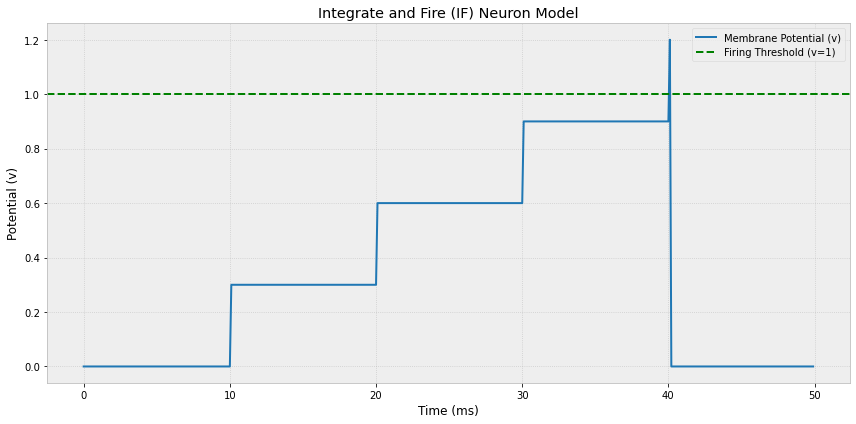

In [5]:
## Integrate and Fire (IF) Neuron Model
# -------------------------------------

# Figure configuration
plt.figure(figsize=(12, 6))
plt.title("Integrate and Fire (IF) Neuron Model")

# Plotting the membrane potential (converting time to ms)
plt.plot(monitor.t / b_ms, monitor.v[0], label='Membrane Potential (v)', lw=2)

# Adding the threshold line
plt.axhline(1, ls='--', c='g', lw=2, label='Firing Threshold (v=1)')

# Axis formatting
plt.xlabel('Time (ms)')
plt.ylabel('Potential (v)')
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [6]:
print("--- Simulation Diagnostics ---")
# Displaying the precise moments when spikes are generated
print(f"Input spike timings: {spike_times}")

# Displaying the temporal resolution
print(f"Number of recorded data points: {len(monitor.v[0])} points")
print(f"Simulation time step (dt): {brian2.defaultclock.dt}")

--- Simulation Diagnostics ---
Input spike timings: [10. 20. 30. 40. 50.] ms
Number of recorded data points: 500 points
Simulation time step (dt): 100. us


### Understanding the Code Logic

The goal is to break down the code structure to properly interpret the resulting graph. The process is divided into three stages: parameter initialization, neuron definition, and connection mapping.

#### Variable Initialization

First, we define the temporal environment and the neuron's dynamics:

```python
# 1. Simulation Parameters
# ------------------------
b_ms = brian2.ms                  # Time base (milliseconds)
duration = 50 * b_ms              # Total simulation duration
n_spikes = 5                      # Number of spikes to generate
inter_spike_interval = 10 * b_ms  # Interval between spikes

# Define spike timings
spike_times = brian2.arange(1, n_spikes + 1) * inter_spike_interval

# Neuron differential equation (Passive IF Model)
# dv/dt = 0 implies that v remains constant between synaptic events.
model_eqs = 'dv/dt = 0/second : 1'    # Neuron differential equation
```

**Key takeaways:**

* **Time Management:** The simulation runs for 50 ms with a spike every 10 ms. The system will generate spikes at 10, 20, 30, 40, and 50 ms.
* **The Equation (`eqs`):** We use a 0-order equation: 
$$\frac{dv}{dt} = 0$$



This implies the derivative of the voltage is zero: between two inputs, the signal suffers no loss (no "leak"). The voltage remains constant until the next event. The `: 1` unit denotes that $v$ is a dimensionless scalar.

#### Defining Groups (Input / Output)

Next, we create the objects that simulate biological behavior:

```python
# 2. Defining Groups (Input & Output)
# -----------------------------------
# Spike Generator: emits spikes at the predefined spike_times
input_group = brian2.SpikeGeneratorGroup(1, [0]*n_spikes, spike_times)

# Output Neuron Group
output_group = brian2.NeuronGroup(
    1, 
    model_eqs, 
    threshold='v > 1', # Firing threshold
    reset='v = 0',     # Reset potential after a spike
    method='euler'     # Numerical integration method
)
```

In this setup, `G_out` monitors the variable $v$. As soon as $v > 1$, the output neuron emits a spike, and its voltage is immediately reset to 0.

#### Synaptic Connection

The synapse bridges the input and the output:

```python
# 3. Synaptic Architecture
# ------------------------
syn = brian2.Synapses(input_group, output_group, on_pre='v += 0.3')
syn.connect(p=1) # Full connection (1-to-1 in this case)
```

The `on_pre='v += 0.3'` parameter is critical: it defines the synaptic weight. Every time a spike arrives from `G_in`, 0.3 is instantly added to the output neuron's voltage $v$. Since the threshold is 1.0, it will take 4 spikes ($4 \times 0.3 = 1.2$) to trigger a reset.

### System Understanding

Now that the code has been analyzed, the graph's behavior becomes clear. As soon as the synapse receives a spike from the `input_group`, it injects a charge into the neuron, increasing its membrane potential by **0.3 V**.

This is visualized as a series of discrete steps: at the first spike, the potential reaches 0.3 V, followed by 0.6 V, 0.9 V, and finally 1.2 V. However, once the voltage exceeds the **1 V threshold**, it is immediately reset to zero. This is the core principle of the system: information integrates until it reaches a critical value, triggering a firing event and a subsequent reset. The behavior of the IF model is summarized in [](#Fonctionnement_IF_EN).

```{table} IF Model Mechanics
:name: Fonctionnement_IF_EN
:align: center

| Condition | Model behavior |
| :--- | :--- |
| On presynaptic spike index $i$ | $v \leftarrow v+w_i$ |
| Threshold condition: fire a spike if | $v > 1$ |
| Reset event: after a spike, set | $v \leftarrow 0$ |
```

## The Integrate and Fire (IF) Neuron: Electronic Approach

### Integrate

#### Electronic Circuit

```{note}
The reference article for the electronic part is as follows: {cite}`Add rajouter`
```

The objective is now to design an "Integrate and Fire" (IF) neuron using electronic components. The first step consists of implementing the integration function. In electronics, the simplest way to integrate a signal is to use a circuit composed of a resistor and a capacitor in series, as illustrated in [](#RC_1_SNN).

```{figure} ./images/RC_1.svg
:name: RC_1_SNN
:align: center
:width: 400px

Elementary model of an RC integrator.
```

To facilitate the subsequent study, two modifications will be made to the basic circuit. First, the resistor is split into two parts to create a **voltage divider**. Second, the input system is a **current source** rather than a voltage source. Using a current source provides a more linear rise time and better reflects the behavior of IF neuron inputs in neuromorphic architectures. The modified circuit is shown in [](#RC_pond_diviseur_SNN).

```{figure} ./images/RC_pond_diviseur.svg
:name: RC_pond_diviseur_SNN
:align: center
:width: 400px

Target model for integration
```

Once the setup is defined, it must be characterized to determine the optimal component values based on the expected behavior.

#### Mathematical Modeling

* **1. Input Signal Analysis**

Unlike numerical simulations that often use Dirac impulses, we are using a **current step** (gate function). Let us consider a current source with an amplitude of $100 \text{ mA}$ applied for a duration of $0.3 \mu\text{s}$.

To convert this current into voltage, we use the fundamental capacitor relationship:

$$i(t) = C \frac{dv(t)}{dt}$$

By isolating the voltage variation $dv(t)$, we obtain:

$$dv(t) = \frac{i(t)}{C} dt$$

The output voltage is therefore the integral of the current divided by the capacitance. For a $1 \mu\text{F}$ capacitor, the peak voltage value ($V_{peak}$) is calculated as follows:

$$V_{peak} = \frac{100 \times 10^{-3} \text{ A} \times 0.3 \times 10^{-6} \text{ s}}{1 \times 10^{-6} \text{ F}} = 30 \text{ mV}$$

In summary, the amplitude of the voltage jump depends exclusively on the intensity of the integrated current and the capacitance value. At this stage, the resistors do not influence the maximum jump value, which remains approximately $300 \text{ mV}$.

* **2. Dynamic Behavior and Discharge**
While the resistors do not affect the peak amplitude, they play a vital role in **maintaining the potential** (the neuron's relaxation phase). Let us analyze the circuit behavior using analytical equations.

Based on Kirchhoff's laws applied to the circuit:
$$I_{input} = I_{R} + I_C$$

By expressing the current in the capacitor ($I_C = C \frac{dV}{dt}$) and the leakage current through the resistors via Ohm's law ($I_R = \frac{V}{R_{eq}}$), we get:

$$C \frac{dV}{dt} = I_{input} - \frac{V}{R_1 + R_2}$$

Isolating the voltage derivative:
$$\frac{dV}{dt} = \frac{I_{input}}{C} - \frac{V}{(R_1 + R_2)C}$$

The general solution for this differential equation is:
$$V(t) = V_{\infty} + (V_0 - V_{\infty}) e^{-\frac{t}{\tau}}$$

Where the time constant $\tau$ is defined as:
$$\tau = R_{eq} \cdot C = (R_1 + R_2) \cdot C$$

The value of $\tau$ determines the rate of potential decay: the smaller $\tau$ is, the faster the neuron "forgets" the integrated information (the *leak* phenomenon).

With the system now characterized, we can proceed to model it using **PySpice**.

In [7]:
# ----------------------------------------------------------------
# Circuit Component Parameters
# ----------------------------------------------------------------
C1 = 1 @ u_uF          # Capacitance value (Microfarads)
R1 = 100 @ u_kOhm      # Resistance 1 value (Kilo-ohms)
R2 = 100 @ u_kOhm      # Resistance 2 value (Kilo-ohms)

# ----------------------------------------------------------------
# Pulse Source Parameters (Current Source)
# ----------------------------------------------------------------
initial_value  = 0 @ u_A       # Initial signal value (Amperes)
peak_amplitude = -100 @ u_mA   # Peak pulse amplitude (Milliamperes)
pulse_period   = 10 @ u_us     # Signal period (Microseconds)
pulse_width    = 0.3 @ u_us    # Pulse duration (Microseconds)
delay_time     = 10 @ u_us     # Initial delay before first pulse (Microseconds)

In [8]:
# ----------------------------------------------------------------
# Discharge and Voltage Droop Analysis
# ----------------------------------------------------------------
# Calculation of the time constant (Tau)
# Note: Ensure C, R1, and R2 are defined with PySpice units
tau = float(C1 * (R1 + R2))

print(f"Time Constant (Tau): {tau * 1e3:.2f} ms")
print(f"95% Discharge Time (3*Tau): {tau * 3 * 1e3:.2f} ms")

# Calculating the voltage droop percentage over a 10µs window
time_window = 10e-6
droop_percentage = (1 - np.exp(-time_window / tau)) * 100

print(f"Voltage Droop Percentage: {droop_percentage:.3f} %")

Time Constant (Tau): 200.00 ms
95% Discharge Time (3*Tau): 600.00 ms
Voltage Droop Percentage: 0.005 %


It can be observed that the time constant $\tau$ is **200 ms**. Consequently, a 95% discharge (which corresponds to approximately $3\tau$) would require **600 ms**. 

This duration is significantly longer than our $10 \mu s$ observation window; thus, the signal does not have sufficient time to lose its charge. The charge loss is only **0.005%**, which is negligible in our case. For the sake of simplicity, this leakage can be treated as zero, and the voltage level can be considered constant.

In [9]:
# ----------------------------------------------------------------
# Circuit Netlist Definition: Leaky Integrator Block
# ----------------------------------------------------------------
circuit = Circuit("Leaky Integrator Block")

# Define the Pulsed Current Source
circuit.PulseCurrentSource(
    'pulse', 'in_pulse', circuit.gnd,
    initial_value = initial_value,
    pulsed_value  = peak_amplitude,
    pulse_width   = pulse_width,
    period        = pulse_period,
    delay_time    = delay_time
    # rise_time   = 1 @ u_ns, # Optional: defined for realistic transitions
    # fall_time   = 1 @ u_ns  # Optional: defined for realistic transitions
)

# Membrane Capacitor (Integrator Core)
circuit.C("mem", 'in_pulse', circuit.gnd, C1)

# Leakage Resistor Network (Voltage Divider / Leak Path)
circuit.R(1, 'in_pulse', 'node_leak_integrator', R1)
circuit.R(2, 'node_leak_integrator', circuit.gnd, R2);

In [10]:
# ============================================================
# Simulation Setup & Execution
# ============================================================

# Create the simulator instance with nominal operating conditions (25°C)
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)

# Perform Transient Analysis
# step_time: simulation resolution | end_time: total duration
analysis = simulator.transient(
    step_time = 0.1 @ u_us,
    end_time  = 50 @ u_us
)

Unsupported Ngspice version 41


In [11]:
# Data Extraction (Converted to NumPy arrays for processing)
time_us = np.array(analysis.time) * 1e6                     # Time in us
v_in     = np.array(analysis['in_pulse']) * 1e3             # Voltage in mV
v_output = np.array(analysis['node_leak_integrator']) * 1e3 # Voltage in mV

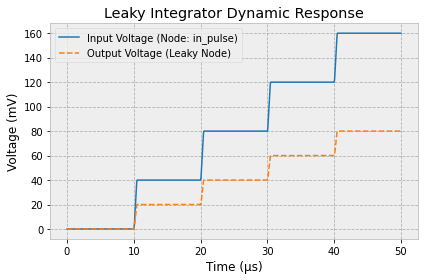

In [12]:
# ============================================================
# Visualization
# ============================================================

plt.figure()
plt.title("Leaky Integrator Dynamic Response")

plt.plot(time_us, v_in, label="Input Voltage (Node: in_pulse)", linewidth=1.5)
plt.plot(time_us, v_output, label="Output Voltage (Leaky Node)", linestyle='--', linewidth=1.5)

plt.xlabel("Time (µs)", fontsize=12)
plt.ylabel("Voltage (mV)", fontsize=12)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

### Discharge Phase

A voltage jump of **40 mV** is observed, although the previous section demonstrated that these jumps should theoretically be **30 mV**. While the source of this **10 mV** discrepancy remains unidentified, the underlying integration calculations remain valid. Having successfully implemented the integration, the next objective is to handle the discharge mechanism.

#### Discharge Implementation - without hysteresis

This section explores how to discharge the capacitor once it reaches a specific threshold. The primary method for rapid discharge is to short-circuit the capacitor, effectively pulling its terminals to ground, as illustrated in [](#RC_court_circuit_SNN).

```{figure} ./images/RC_court_circuit.svg
:name: RC_court_circuit_SNN
:align: center
:width: 400px

RC circuit with resistance short-circuiting
```

Consequently, the circuit must be designed to trigger a short-circuit across the capacitor as soon as the threshold voltage is exceeded.

```{danger}
* **Current Limiting:** A capacitor should never be short-circuited directly; doing so induces a high-current spike (inrush current) that may damage circuit components. Therefore, a small discharge resistor must always be included in the discharge path.
* **Model Simplification:** For this stage of the study, we will utilize an ideal switch model. Implementing a **Silicon Controlled Rectifier (SCR)** with input hysteresis is significantly more complex to design and simulate; hence, a simplified behavioral model is preferred for initial verification.
```

The circuit under evaluation is shown in [](#leak_integrator_descante_SNN). It incorporates the previously discussed components—current source, capacitor, and current divider—while introducing a thyristor and a pull-down resistor.

```{figure} ./images/leak_integrator_descante.svg
:name: leak_integrator_descante_SNN
:align: center
:width: 400px

Leaky integrator circuit with discharge mechanism
```

```{warning}
Component values have been modified to simplify the subsequent analysis and to emphasize the voltage steps (plateaus) for better visibility.
```

In [13]:
# ----------------------------------------------------------------
# Circuit Component Parameters
# ----------------------------------------------------------------
C1     = 100 @ u_nF     # Capacitance value (Nanofarads)
R1     = 0 @ u_kOhm     # Resistance 1 value (Kilo-ohms)
R2     = 2000 @ u_kOhm  # Resistance 2 value (Kilo-ohms)
R_pull = 25 @ u_Ohm     # Pull-down resistance value (ohms)

# ----------------------------------------------------------------
# Pulse Source Parameters (Current Source)
# ----------------------------------------------------------------
initial_value  = 0 @ u_A       # Initial signal value (Amperes)
peak_amplitude = -100 @ u_mA   # Peak pulse amplitude (Milliamperes)
pulse_period   = 10 @ u_us     # Signal period (Microseconds)
pulse_width    = 0.3 @ u_us    # Pulse duration (Microseconds)
delay_time     = 10 @ u_us     # Initial delay before first pulse (Microseconds)

In [14]:
## Creation du circuit
# --------------------
circuit = Circuit("Leaky Integrator Circuit with Discharge Mechanism Block")

## Input
# ------
# Define the Pulsed Current Source
circuit.PulseCurrentSource(
    'pulse',                        # Name
    'in_pulse', circuit.gnd,        # Borne
    initial_value = initial_value,
    pulsed_value  = peak_amplitude,
    pulse_width   = pulse_width,
    period        = pulse_period,
    delay_time    = delay_time
)

## Integration
# ------------
# Membrane Capacitor (Integrator Core)
circuit.C("mem", 'in_pulse', circuit.gnd, C1)

# Leakage Resistor Network (Voltage Divider / Leak Path)
circuit.R(1, 'in_pulse', 'node_leak_integrator', R1)
circuit.R(2, 'node_leak_integrator', circuit.gnd, R2)


## discharge mechanism
# --------------------
# Modele switch
circuit.model(
    'SW1', 'SW',           # Name and model 
    Ron  = 1  @ u_Ohm,     # Resistance when the switch is closed
    Roff = 1  @ u_MOhm,    # Resistance when the switch is open
    Vt   = 1  @ u_V,       # Threshold voltage
    Vh   = 0  @u_V,        # Hysteresis tension
)

# switch
circuit.S('leak_switch',                        # Name
          'in_pulse', 'node_reset',             # Switch born
          'node_leak_integrator', circuit.gnd,  # Commande
          model='SW1'                           # Model
)

# Pulling resistance
circuit.R(
    'pull_down',                # Name
    'node_reset', circuit.gnd,  # Resistance born
    R_pull,                     # Value resistance
);

In [15]:
# ============================================================
# Simulation Setup & Execution
# ============================================================

# Create the simulator instance with nominal operating conditions (25°C)
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)

# Perform Transient Analysis
# step_time: simulation resolution | end_time: total duration
analysis = simulator.transient(
    step_time = 0.1 @ u_us,
    end_time  = 50 @ u_us
)

In [16]:
time   = np.array(analysis.time)*1e6
output = np.array(analysis["node_leak_integrator"])

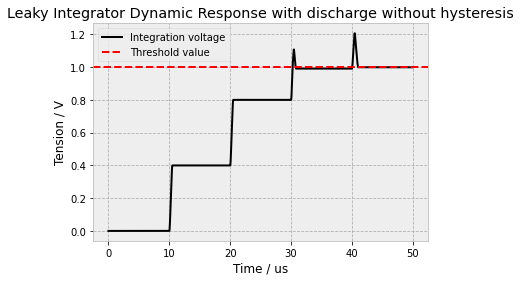

In [17]:
plt.figure()

plt.title("Leaky Integrator Dynamic Response with discharge without hysteresis")

plt.plot(time, output, label="Integration voltage", c="k")

plt.axhline(1, label="Threshold value", c="red", ls="--")

plt.legend()
plt.ylabel("Tension / V")
plt.xlabel("Time / us")
plt.show()

It is observed that the system does not behave as intended. When the voltage exceeds the threshold (set here at $1\text{ V}$), it decreases only until it returns to this threshold value. However, the objective is for the capacitor to discharge completely. To achieve this, a hysteresis loop must be implemented.

#### Discharge Implementation - with hysteresis

The goal is for the switch to close when the voltage reaches a value higher than the $1\text{ V}$ threshold and only open once the transistor voltage is near $0\text{ V}$. The output hysteresis is defined as follows [](#hysteresis_switch_LI_SNN): the center value is $0.45\text{ V}$ with a span (amplitude) of $0.44\text{ V}$. Consequently, the lower switching threshold is $0.01\text{ V}$ and the upper threshold is $0.95\text{ V}$.

```{figure} ./images/hysteresis_switch_LI.svg
:name: hysteresis_switch_LI_SNN
:align: center
:width: 400px

Hysteresis loop showing when the switch is closed or open
```

```{warning} Hysteresis values
One must avoid setting the lower threshold too close to zero. The closer the threshold is to zero, the longer it takes for the capacitor to discharge. Furthermore, if this threshold is too low, the transistor risks remaining closed and failing to reopen.

In our case, with a $50\ \Omega$ pull-up resistor and a $1\ \Omega$ switch resistance, the equivalent resistance is $51\ \Omega$. With a capacitance of $100\text{ nF}$, the time constant is $\tau = 5.1\ \mu\text{s}$. To reach $0.01\text{ V}$ starting from $V_0 = 1\text{ V}$, the calculation is:

$$t_{0.01} = -\ln(0.01) \cdot \tau \approx 23.34\ \mu\text{s}$$

While simulations show that this configuration works, the design margin is quite narrow.
```

In [18]:
# ----------------------------------------------------------------
# Circuit Component Parameters
# ----------------------------------------------------------------
C1     = 100 @ u_nF     # Capacitance value (Nanofarads)
R1     = 0 @ u_kOhm     # Resistance 1 value (Kilo-ohms)
R2     = 2000 @ u_kOhm  # Resistance 2 value (Kilo-ohms)
R_pull = 10 @ u_Ohm     # Pull-down resistance value (ohms)

# ----------------------------------------------------------------
# Pulse Source Parameters (Current Source)
# ----------------------------------------------------------------
initial_value  = 0 @ u_A       # Initial signal value (Amperes)
peak_amplitude = -100 @ u_mA   # Peak pulse amplitude (Milliamperes)
pulse_period   = 10 @ u_us     # Signal period (Microseconds)
pulse_width    = 0.3 @ u_us    # Pulse duration (Microseconds)
delay_time     = 10 @ u_us     # Initial delay before first pulse (Microseconds)

In [19]:
## Creation du circuit
# --------------------
circuit = Circuit("Leaky Integrator Circuit with Discharge Mechanism Block and Hysteresis")

## Input
# ------
# Define the Pulsed Current Source
circuit.PulseCurrentSource(
    'pulse',                        # Name
    'in_pulse', circuit.gnd,        # Borne
    initial_value = initial_value,
    pulsed_value  = peak_amplitude,
    pulse_width   = pulse_width,
    period        = pulse_period,
    delay_time    = delay_time
)

## Integration
# ------------
# Membrane Capacitor (Integrator Core)
circuit.C("mem", 'in_pulse', circuit.gnd, C1)

# Leakage Resistor Network (Voltage Divider / Leak Path)
circuit.R(1, 'in_pulse', 'node_leak_integrator', R1)
circuit.R(2, 'node_leak_integrator', circuit.gnd, R2)

## discharge mechanism
# --------------------
# modele switch with hysteresis
circuit.model(
    'SW1', 'SW',       # Name and model 
    Ron  = 10@u_Ohm,   # Resistance when the switch is closed
    Roff = 10@u_MOhm,  # Resistance when the switch is open
    Vt   = 0.45@u_V,   # Threshold voltage
    Vh   = 0.44@u_V,   # Hysteresis tension
)

# switch
circuit.S('leak_switch',                        # Name
          'in_pulse', 'node_reset',             # Switch born
          'node_leak_integrator', circuit.gnd,  # Commande
          model='SW1'                           # Model
)

# Pulling resistance
circuit.R(
    'pull_down',                # Name
    'node_reset', circuit.gnd,  # Resistance born
    R_pull,                     # Value resistance
);

In [20]:
# ============================================================
# Simulation Setup & Execution
# ============================================================

# Create the simulator instance with nominal operating conditions (25°C)
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)

# Perform Transient Analysis
# step_time: simulation resolution | end_time: total duration
analysis = simulator.transient(
    step_time = 0.1 @ u_us,
    end_time  = 50 @ u_us
)

In [21]:
time   = np.array(analysis.time)*1e6                 # Time in micro-second
output = np.array(analysis["node_leak_integrator"])  # Output value of tension

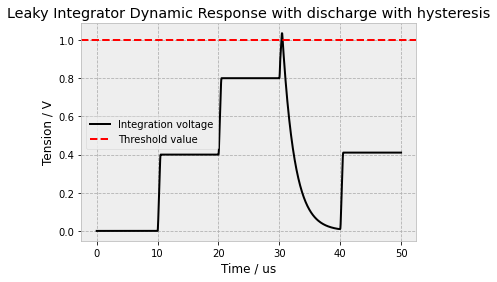

In [22]:
plt.figure()

plt.title("Leaky Integrator Dynamic Response with discharge with hysteresis")

plt.plot(time, output, label="Integration voltage", c="k")

plt.axhline(1, label="Threshold value", c="red", ls="--")

plt.legend()
plt.ylabel("Tension / V")
plt.xlabel("Time / us")
plt.show()

This time, the result matches the expectations. The process begins with an integration phase; then, once the integration signal exceeds a specific threshold (in our case $1\text{ V}$), the capacitor discharges almost completely. A small residual charge of approximately $0.01\text{ V}$ remains in the capacitor.

One should never attempt to reach exactly $0\text{ V}$. If the threshold is set too low, there is a risk that the discharge cycle may never properly reset, potentially causing an unintended spike to appear immediately afterward, as shown in the next section. Therefore, it is essential to maintain a safety margin to ensure the capacitor can complete its discharge phase while reaching the target value relatively quickly.

#### Threshold value too low

In [23]:
# ----------------------------------------------------------------
# Circuit Component Parameters
# ----------------------------------------------------------------
C1     = 100 @ u_nF     # Capacitance value (Nanofarads)
R1     = 0 @ u_kOhm     # Resistance 1 value (Kilo-ohms)
R2     = 2000 @ u_kOhm  # Resistance 2 value (Kilo-ohms)
R_pull = 10 @ u_Ohm     # Pull-down resistance value (ohms)

# ----------------------------------------------------------------
# Pulse Source Parameters (Current Source)
# ----------------------------------------------------------------
initial_value  = 0 @ u_A       # Initial signal value (Amperes)
peak_amplitude = -100 @ u_mA   # Peak pulse amplitude (Milliamperes)
pulse_period   = 10 @ u_us     # Signal period (Microseconds)
pulse_width    = 0.3 @ u_us    # Pulse duration (Microseconds)
delay_time     = 10 @ u_us     # Initial delay before first pulse (Microseconds)

In [24]:
## Creation du circuit
# --------------------
circuit = Circuit("Leaky Integrator Circuit with Discharge Mechanism Block and Hysteresis")

## Input
# ------
# Define the Pulsed Current Source
circuit.PulseCurrentSource(
    'pulse',                        # Name
    'in_pulse', circuit.gnd,        # Borne
    initial_value = initial_value,
    pulsed_value  = peak_amplitude,
    pulse_width   = pulse_width,
    period        = pulse_period,
    delay_time    = delay_time
)

## Integration
# ------------
# Membrane Capacitor (Integrator Core)
circuit.C("mem", 'in_pulse', circuit.gnd, C1)

# Leakage Resistor Network (Voltage Divider / Leak Path)
circuit.R(1, 'in_pulse', 'node_leak_integrator', R1)
circuit.R(2, 'node_leak_integrator', circuit.gnd, R2)

## discharge mechanism
# --------------------
# modele switch with hysteresis
circuit.model(
    'SW1', 'SW',       # Name and model 
    Ron  = 10@u_Ohm,   # Resistance when the switch is closed
    Roff = 10@u_MOhm,  # Resistance when the switch is open
    Vt   = 0.50@u_V,   # Threshold voltage
    Vh   = 0.50@u_V,   # Hysteresis tension
)

# switch
circuit.S('leak_switch',                        # Name
          'in_pulse', 'node_reset',             # Switch born
          'node_leak_integrator', circuit.gnd,  # Commande
          model='SW1'                           # Model
)

# Pulling resistance
circuit.R(
    'pull_down',                # Name
    'node_reset', circuit.gnd,  # Resistance born
    R_pull,                     # Value resistance
);

In [25]:
# ============================================================
# Simulation Setup & Execution
# ============================================================

# Create the simulator instance with nominal operating conditions (25°C)
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)

# Perform Transient Analysis
# step_time: simulation resolution | end_time: total duration
analysis = simulator.transient(
    step_time = 0.1 @ u_us,
    end_time  = 50 @ u_us
)

In [26]:
time   = np.array(analysis.time)*1e6                 # Time in micro-second
output = np.array(analysis["node_leak_integrator"])  # Output value of tension

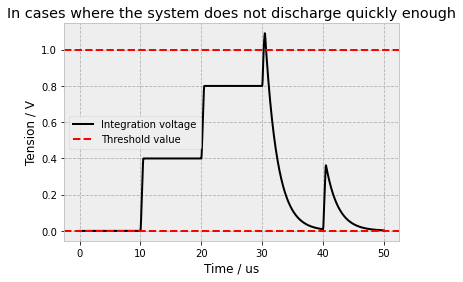

In [27]:
plt.figure()

plt.title("In cases where the system does not discharge quickly enough")

plt.plot(time, output, label="Integration voltage", c="k")

plt.axhline(1, c="red", ls="--", label="Threshold value")
plt.axhline(0, c="red", ls="--")

plt.legend()
plt.ylabel("Tension / V")
plt.xlabel("Time / us")
plt.show()

It can be observed that the voltage never reaches the lower threshold value (in this case 0 V). This occurs because the capacitor does not have sufficient time to discharge before the next peak arrives; as a result, the switch remains closed and fails to reopen. This is an incorrect behavior. Consequently, care must be taken to ensure that the capacitor can discharge quickly enough to meet the system's timing requirements.

### Fires

In the following section, the objective is to produce a clean voltage spike whenever the switch closes. To achieve this, a transistor must be added along with an output capacitor. The goal is to obtain a controlled pulse that remains consistent and uniform over time. The circuit design is shown below [](#leak_integrator_fires_SNN).

```{figure} ./images/leak_integrator_fires.svg
:name: leak_integrator_fires_SNN
:align: center
:width: 600px

Circuit diagram with the "Fires" stage
```

In [28]:
# ----------------------------------------------------------------
# Circuit Component Parameters
# ----------------------------------------------------------------
C1      = 50 @ u_nF          # Capacitance value (Nanofarads)
R1     = 0 @ u_kOhm          # Resistance 1 value (Kilo-ohms)
R2     = 2000 @ u_kOhm       # Resistance 2 value (Kilo-ohms)
R_pull = 10   @ u_Ohm        # Pull-down resistance value (ohms)
R_time_palier = 5  @ u_kOhm  # Time palier resistance value (Kilo-ohms)

# ----------------------------------------------------------------
# Pulse Source Parameters (Current Source)
# ----------------------------------------------------------------
initial_value  = 0 @ u_A       # Initial signal value (Amperes)
peak_amplitude = -100 @ u_mA   # Peak pulse amplitude (Milliamperes)
pulse_period   = 10 @ u_us     # Signal period (Microseconds)
pulse_width    = 0.3 @ u_us    # Pulse duration (Microseconds)
delay_time     = 10 @ u_us     # Initial delay before first pulse (Microseconds)

# ----------------------------------------------------------------
# Supply voltage
# ----------------------------------------------------------------
VDD = 3.3 @ u_V                # Supply voltage (Voltage)

In [29]:
# ============================================================
# Circuit Definition
# ============================================================
circuit = Circuit("Leaky integrator Block with Fires")

# ============================================================
# Library Imports
# ============================================================
# Include standard MOSFET models (ensure BSS123 is defined here)
circuit.include('lib/standard.mos')

# ============================================================
# Power Supply & Input Stimulus
# ============================================================
# DC Power Supply (VDD)
circuit.V('dd', 'vdd', circuit.gnd, VDD)

# Define the Pulsed Current Source
circuit.PulseCurrentSource(
    'pulse',                        # Name
    'in_pulse', circuit.gnd,        # Positive node, Negative node
    initial_value = initial_value,
    pulsed_value  = peak_amplitude,
    pulse_width   = pulse_width,
    period        = pulse_period,
    delay_time    = delay_time
)

# ============================================================
# Leaky Integrator Core
# ============================================================
# Membrane Capacitor (Integrator Core)
circuit.C("mem", 'in_pulse', circuit.gnd, C1)

# Leakage Resistor Network (Voltage Divider / Leak Path)
circuit.R(1, 'in_pulse', 'node_leak_integrator', R1)
circuit.R(2, 'node_leak_integrator', circuit.gnd, R2)

# ============================================================
# Discharge & Reset Mechanism
# ============================================================
# Voltage-Controlled Switch Model (with Hysteresis)
circuit.model(
    'SW1', 'SW',
    Ron  = 1@u_Ohm,
    Roff = 10@u_MOhm,
    Vt   = 1.45@u_V,
    Vh   = 1.44@u_V
)

# Voltage-Controlled Switch Instance
circuit.S('leak_switch',
          'in_pulse', 'node_reset',
          'node_leak_integrator', circuit.gnd,
          model='SW1');

# Pull-Down Resistor for the Reset Node
# Ensures the MOSFET gate is firmly grounded (0V) when the switch is open
circuit.R('pull_down', 'node_reset', circuit.gnd, R_pull);


# ============================================================
# Pulse Generation (Fire Step)
# ============================================================
# NMOS Transistor (Pulse generator)
circuit.MOSFET(
    1,
    'node_fires',   # Drain  : Connected to the Pull-Up resistor
    'node_reset',   # Gate   : Receives the voltage spike from the switch
    circuit.gnd,    # Source : Connected to ground (Low-Side configuration)
    circuit.gnd,    # Bulk   : Connected to ground
    model='BSS123',
)

# Pull-Up Resistor (to VDD)
# Makes the "node_fires" signal Active-Low (VDD at rest, 0V during the pulse)
circuit.R(3, 'node_fires', 'vdd', R_time_palier);

In [30]:
# ============================================================
# Simulation Setup & Execution
# ============================================================

# Create the simulator instance with nominal operating conditions (25°C)
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)

# Perform Transient Analysis
# step_time: simulation resolution | end_time: total duration
analysis = simulator.transient(
    step_time = 0.1 @ u_us,
    end_time  = 50 @ u_us
)

In [31]:
time        = np.array(analysis.time)*1e6                 # Time in micro-second
integration = np.array(analysis["node_leak_integrator"])  # Integration value (Voltage)
fires       = np.array(analysis["node_fires"])            # Fires value (Voltage)

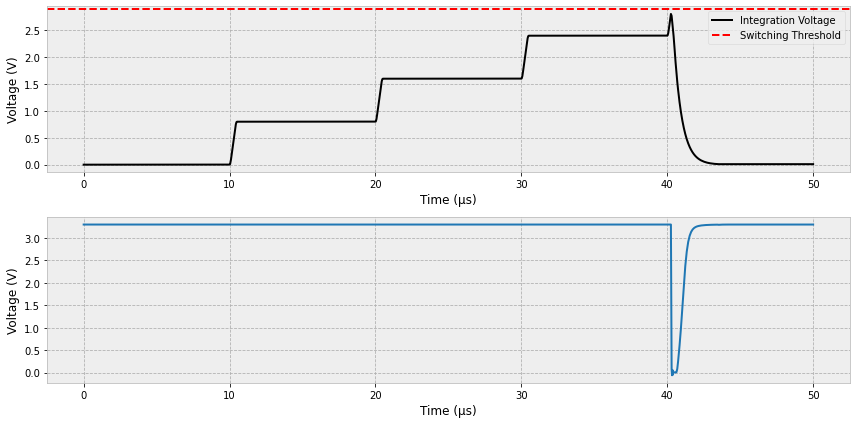

In [32]:
plt.figure(figsize=(12, 6))

# First subplot: Integration signal and hysteresis threshold
plt.subplot(211)
plt.plot(time, integration, label="Integration Voltage", c="k")
# Displaying the upper hysteresis threshold (Threshold = 0.89 V)
plt.axhline(1.45 + 1.44, label="Switching Threshold", c="red", ls="--")
plt.legend()
plt.ylabel("Voltage (V)")
plt.xlabel("Time (µs)")

# Second subplot: "Fires" output signal
plt.subplot(212)
plt.plot(time, fires, label="Fires Signal (Output)")
plt.ylabel("Voltage (V)")
plt.xlabel("Time (µs)")

plt.tight_layout()
plt.show()

Il est possible de voir que pour l'instant, il y a un pic mais que ce pic est à l'envers. L'état d'attente est à 3.3V, mais lorsque le switch se ferme alors la tension de sortie baisse d'un coup. Pour aller proche de zéros.  Donc l'objectif de la prochaine partie est d'avoir le système inverse. Pour cela il faut rajouter un buffer qui est quasiment le même système que vu précédement.

### Buffer

L'objectif du buffer est double tout d'abord simplifier la connecxion avec d'autre composant, mais aussi avoir le rôle d'inverseur. Le montage est le suivant [](#) au lieu d'utiliser un NMOS, cette fois c'est un PMOS qui est utilisé donc qui d'active lorsque la tension de grille est proche de $0 V$ et la différence entre le système fires et le buffer et que l'on passe d'un NMOS à un PMOS, il ne faut pas oublier d'inverser la résistance de tirage qui pour le NMOS est entre la VDD et la source du transistor, mais pour un PMOS il doit être entre le drain et la masse. 

```{figure} ./images/leak_integrator_fires_buffer.svg
:name: leak_integrator_fires_buffer_SNN
:align: center
:width: 600px

Circuit avec le buffer
```


In [33]:
# ----------------------------------------------------------------
# Circuit Component Parameters
# ----------------------------------------------------------------
C1      = 50 @ u_nF          # Capacitance value (Nanofarads)
R1     = 0 @ u_kOhm          # Resistance 1 value (Kilo-ohms)
R2     = 2000 @ u_kOhm       # Resistance 2 value (Kilo-ohms)
R_pull = 10   @ u_Ohm        # Pull-down resistance value (ohms)
R_time_palier = 5  @ u_kOhm  # Time palier resistance value (Kilo-ohms)

# ----------------------------------------------------------------
# Pulse Source Parameters (Current Source)
# ----------------------------------------------------------------
initial_value  = 0 @ u_A       # Initial signal value (Amperes)
peak_amplitude = -100 @ u_mA   # Peak pulse amplitude (Milliamperes)
pulse_period   = 10 @ u_us     # Signal period (Microseconds)
pulse_width    = 0.3 @ u_us    # Pulse duration (Microseconds)
delay_time     = 10 @ u_us     # Initial delay before first pulse (Microseconds)

# ----------------------------------------------------------------
# Supply voltage
# ----------------------------------------------------------------
VDD = 3.3 @ u_V                # Supply voltage (Voltage)

In [34]:
# ============================================================
# Circuit Definition
# ============================================================
circuit = Circuit("Leaky integrator Block with Buffer")

# ============================================================
# Library Imports
# ============================================================
# Include standard MOSFET models (ensure BSS123 is defined here)
circuit.include('lib/standard.mos')

# ============================================================
# Power Supply & Input Stimulus
# ============================================================
# DC Power Supply (VDD)
circuit.V('dd', 'vdd', circuit.gnd, VDD)

# Define the Pulsed Current Source
circuit.PulseCurrentSource(
    'pulse',                        # Name
    'in_pulse', circuit.gnd,        # Positive node, Negative node
    initial_value = initial_value,
    pulsed_value  = peak_amplitude,
    pulse_width   = pulse_width,
    period        = pulse_period,
    delay_time    = delay_time
)

# ============================================================
# Leaky Integrator Core
# ============================================================
# Membrane Capacitor (Integrator Core)
circuit.C("mem", 'in_pulse', circuit.gnd, C1)

# Leakage Resistor Network (Voltage Divider / Leak Path)
circuit.R(1, 'in_pulse', 'node_leak_integrator', R1)
circuit.R(2, 'node_leak_integrator', circuit.gnd, R2)

# ============================================================
# Discharge & Reset Mechanism
# ============================================================
# Voltage-Controlled Switch Model (with Hysteresis)
circuit.model(
    'SW1', 'SW',
    Ron  = 1@u_Ohm,
    Roff = 10@u_MOhm,
    Vt   = 1.45@u_V,
    Vh   = 1.44@u_V
)

# Voltage-Controlled Switch Instance
circuit.S('leak_switch',
          'in_pulse', 'node_reset',
          'node_leak_integrator', circuit.gnd,
          model='SW1');

# Pull-Down Resistor for the Reset Node
# Ensures the MOSFET gate is firmly grounded (0V) when the switch is open
circuit.R('pull_down', 'node_reset', circuit.gnd, R_pull);


# ============================================================
# Pulse Generation (Fire Step)
# ============================================================
# NMOS Transistor (Pulse generator)
circuit.MOSFET(
    1,
    'node_fires',   # Drain  : Connected to the Pull-Up resistor
    'node_reset',   # Gate   : Receives the voltage spike from the switch
    circuit.gnd,    # Source : Connected to ground (Low-Side configuration)
    circuit.gnd,    # Bulk   : Connected to ground
    model='BSS123',
)

# Pull-Up Resistor (to VDD)
# Makes the "node_fires" signal Active-Low (VDD at rest, 0V during the pulse)
circuit.R(3, 'node_fires', 'vdd', R_time_palier)

# =========================================================
# ETAGE 2 : Le Buffer PMOS (BSS84)
# =========================================================
circuit.MOSFET(
    2,
    'node_output',  # Drain : Connecté à la sortie et à la Pull-DOWN
    'node_fires',   # Gate  : Reçoit le signal actif bas du NMOS
    'vdd',          # Source: Connecté au VDD (High-Side)
    'vdd',          # Bulk  : Connecté au VDD
    model='BSS84',
)
# Résistance Pull-DOWN (10 kOhm) vers la masse
# -> Remet le signal à l'endroit : 0V au repos, 3.3V au pic !
circuit.R(4, 'node_output', circuit.gnd, R_time_palier);

In [35]:
# ============================================================
# Simulation Setup & Execution
# ============================================================

# Create the simulator instance with nominal operating conditions (25°C)
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)

# Perform Transient Analysis
# step_time: simulation resolution | end_time: total duration
analysis = simulator.transient(
    step_time = 0.1 @ u_us,
    end_time  = 50 @ u_us
)

In [36]:
time        = np.array(analysis.time)*1e6                 # Time in micro-second
integration = np.array(analysis["node_leak_integrator"])  # Integration value (Voltage)
fires       = np.array(analysis["node_fires"])            # Fires value (Voltage)
buffer      = np.array(analysis["node_output"])           # Output value (Voltage)

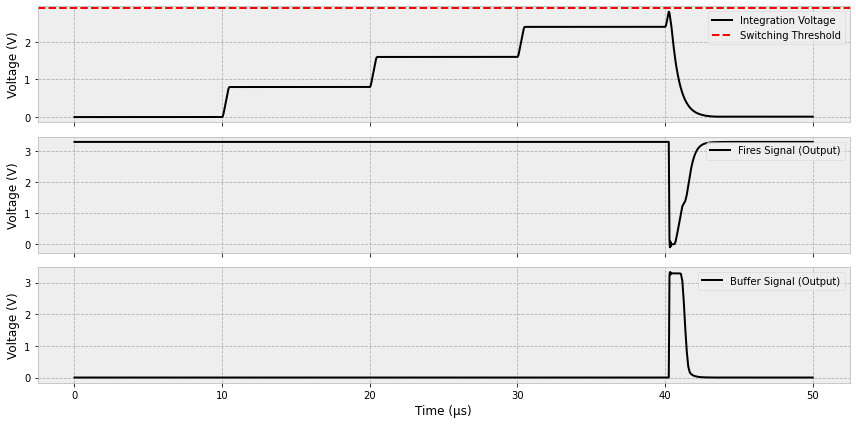

In [37]:
# Create a figure with 3 subplots sharing the same X-axis
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

# First subplot: Integration voltage and switching threshold
ax1.plot(time, integration, color="black", label="Integration Voltage")
# Displaying the upper hysteresis threshold (e.g., 2.89 V)
ax1.axhline(y=(1.45 + 1.44), color="red", linestyle="--", label="Switching Threshold")
ax1.set_ylabel("Voltage (V)")
ax1.legend(loc="upper right")

# Second subplot: 'Fires' output signal
ax2.plot(time, fires, color="k", label="Fires Signal (Output)")
ax2.set_ylabel("Voltage (V)")
ax2.legend(loc="upper right")

# Third subplot: 'Buffer' output signal
ax3.plot(time, buffer, color="k", label="Buffer Signal (Output)")
ax3.set_ylabel("Voltage (V)")
ax3.set_xlabel("Time (µs)") # Only the bottom subplot needs the X-axis label
ax3.legend(loc="upper right")

# Adjust spacing to prevent overlapping
plt.tight_layout()
plt.show()

This time, a clear output voltage spike is observed. When the input reaches a specific threshold, the integrated voltage drops to zero, simultaneously triggering the output spike. The spike's amplitude can be adjusted via the VDD setting, and its duration via resistors $R3$ and $R4$. The objective of the next section is to introduce a leakage (decay) in the integration process, transitioning from a standard Integrate-and-Fire neuron to a Leaky Integrate-and-Fire (LIF) neuron.

## Leaky Integrate-and-Fire (LIF) Neuron

### Simulation

The goal is to make the model more realistic. Unlike the previous model, we introduce energy loss (leakage) over time. This adds a critical dynamic: if two input spikes are too far apart temporally, they will not interact.

The previous model's equation was:

$$\frac{dv}{dt}=0$$

The new model is governed by the following equation:

$$\tau\frac{dv}{dt}=-v$$

This is a first-order differential equation resulting in an exponential decay, where $\tau$ is the system's time constant. Table [](#Fonctionnement_LIF_EN) summarizes the LIF model mechanics.

```{table} LIF Model Mechanics
:name: Fonctionnement_LIF_EN
:align: center

| Condition                                      | Model Behavior            |
| ---------------------------------------------- | ------------------------- |
| Continuous time evolution                      | $\tau\frac{dv}{dt}=-v$    |
| Upon presynaptic spike index $i$               | $v \leftarrow v + w_i$    |
| Threshold condition (fire a spike if)          | $v > 1$                   |
| Reset event (after a spike is fired)           | $v \leftarrow 0$          |
```

To clarify the mechanics in [](#Fonctionnement_LIF_EN): the voltage undergoes continuous exponential decay. When an input spike occurs, the voltage jumps by an amount equal to $w_i$. This process continues until the voltage exceeds a threshold. Once the threshold is crossed, a spike is fired and the voltage is reset to 0 V. Mathematically, this is expressed as follows:

In [38]:
# 1. Simulation Parameters
# ------------------------
b_ms = brian2.ms                  # Time base (milliseconds)
duration = 50 * b_ms              # Total simulation duration
n_spikes = 5                      # Number of spikes to generate
inter_spike_interval = 10 * b_ms  # Interval between spikes

# Define spike timings
spike_times = brian2.arange(1, n_spikes + 1) * inter_spike_interval

# Neuron differential equation (Leaky Integrate-and-Fire Model)
# dv/dt = -v/tau implies an exponential decay (leakage) of the membrane potential.
model_eqs = '''
dv/dt = -v/(15*ms) : 1
'''

# 2. Defining Groups (Input & Output)
# -----------------------------------
# Spike Generator: emits spikes at the predefined spike_times
input_group = brian2.SpikeGeneratorGroup(1, [0]*n_spikes, spike_times)

# Output Neuron Group
output_group = brian2.NeuronGroup(
    1, 
    model_eqs, 
    threshold='v > 1', # Firing threshold
    reset='v = 0',     # Reset potential after a spike
    method='euler'     # Numerical integration method
)

# 3. Synaptic Architecture
# ------------------------
# When a presynaptic spike arrives, the membrane potential jumps by 0.6
syn = brian2.Synapses(input_group, output_group, on_pre='v += 0.6')
syn.connect(p=1) # Full connection (1-to-1)

# 4. Monitoring and Simulation
# ----------------------------
monitor = brian2.StateMonitor(output_group, 'v', record=True)

brian2.run(duration)

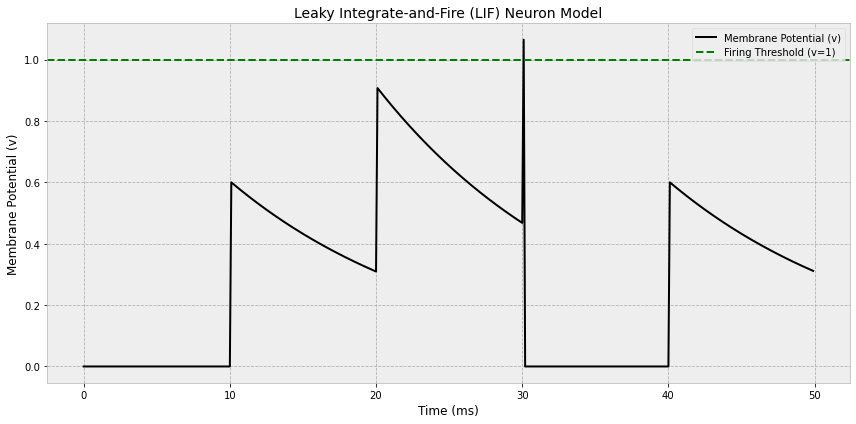

In [39]:
# 5. Plotting the Results
# -----------------------
plt.figure(figsize=(12, 6))
plt.title("Leaky Integrate-and-Fire (LIF) Neuron Model", fontsize=14)

# Plotting the membrane potential (converting time to ms)
plt.plot(monitor.t / b_ms, monitor.v[0], label='Membrane Potential (v)', lw=2, color="black")

# Adding the threshold line
plt.axhline(y=1, linestyle='--', color='green', lw=2, label='Firing Threshold (v=1)')

# Axis formatting
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('Membrane Potential (v)', fontsize=12)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Electronics

To adapt the previous circuit and introduce charge leakage, one simply needs to adjust the value of the capacitor or the resistors to modify the time constant $\tau$.

$$\tau=R_{eq}\cdot C$$

To tune the decay rate, there are two primary approaches. The first is to modify the capacitance $C$: decreasing $C$ will cause the integrated voltage to rise more sharply during a pulse. The second is to adjust the resistors, which directly dictate the value of $\tau$. Finally, a voltage divider can be used to control the amplitude of the applied spikes.

In [40]:
# ----------------------------------------------------------------
# Circuit Component Parameters
# ----------------------------------------------------------------
C1      = 10 @ u_nF          # Capacitance value (Nanofarads)
R1     = 700 @ u_Ohm         # Resistance 1 value (Kilo-ohms)
R2     = 600 @ u_Ohm         # Resistance 2 value (Kilo-ohms)
R_pull = 10   @ u_Ohm        # Pull-down resistance value (ohms)
R_time_palier = 5  @ u_kOhm  # Time palier resistance value (Kilo-ohms)

# ----------------------------------------------------------------
# Pulse Source Parameters (Current Source)
# ----------------------------------------------------------------
initial_value  = 0 @ u_A       # Initial signal value (Amperes)
peak_amplitude = -100 @ u_mA   # Peak pulse amplitude (Milliamperes)
pulse_period   = 10 @ u_us     # Signal period (Microseconds)
pulse_width    = 0.3 @ u_us    # Pulse duration (Microseconds)
delay_time     = 10 @ u_us     # Initial delay before first pulse (Microseconds)

# ----------------------------------------------------------------
# Supply voltage
# ----------------------------------------------------------------
VDD = 3.3 @ u_V                # Supply voltage (Voltage)

In [41]:
# ============================================================
# Circuit Definition
# ============================================================
circuit = Circuit("Leaky integrator Block with Buffer")

# ============================================================
# Library Imports
# ============================================================
# Include standard MOSFET models (ensure BSS123 is defined here)
circuit.include('lib/standard.mos')

# ============================================================
# Power Supply & Input Stimulus
# ============================================================
# DC Power Supply (VDD)
circuit.V('dd', 'vdd', circuit.gnd, VDD)

# Define the Pulsed Current Source
circuit.PulseCurrentSource(
    'pulse',                        # Name
    'in_pulse', circuit.gnd,        # Positive node, Negative node
    initial_value = initial_value,
    pulsed_value  = peak_amplitude,
    pulse_width   = pulse_width,
    period        = pulse_period,
    delay_time    = delay_time
)

# ============================================================
# Leaky Integrator Core
# ============================================================
# Membrane Capacitor (Integrator Core)
circuit.C("mem", 'in_pulse', circuit.gnd, C1)

# Leakage Resistor Network (Voltage Divider / Leak Path)
circuit.R(1, 'in_pulse', 'node_leak_integrator', R1)
circuit.R(2, 'node_leak_integrator', circuit.gnd, R2)

# ============================================================
# Discharge & Reset Mechanism
# ============================================================
# Voltage-Controlled Switch Model (with Hysteresis)
circuit.model(
    'SW1', 'SW',
    Ron  = 1@u_Ohm,
    Roff = 10@u_MOhm,
    Vt   = 1.45@u_V,
    Vh   = 1.44@u_V
)

# Voltage-Controlled Switch Instance
circuit.S('leak_switch',
          'in_pulse', 'node_reset',
          'node_leak_integrator', circuit.gnd,
          model='SW1');

# Pull-Down Resistor for the Reset Node
# Ensures the MOSFET gate is firmly grounded (0V) when the switch is open
circuit.R('pull_down', 'node_reset', circuit.gnd, R_pull);


# ============================================================
# Pulse Generation (Fire Step)
# ============================================================
# NMOS Transistor (Pulse generator)
circuit.MOSFET(
    1,
    'node_fires',   # Drain  : Connected to the Pull-Up resistor
    'node_reset',   # Gate   : Receives the voltage spike from the switch
    circuit.gnd,    # Source : Connected to ground (Low-Side configuration)
    circuit.gnd,    # Bulk   : Connected to ground
    model='BSS123',
)

# Pull-Up Resistor (to VDD)
# Makes the "node_fires" signal Active-Low (VDD at rest, 0V during the pulse)
circuit.R(3, 'node_fires', 'vdd', R_time_palier)

# =========================================================
# ETAGE 2 : Le Buffer PMOS (BSS84)
# =========================================================
circuit.MOSFET(
    2,
    'node_output',  # Drain : Connecté à la sortie et à la Pull-DOWN
    'node_fires',   # Gate  : Reçoit le signal actif bas du NMOS
    'vdd',          # Source: Connecté au VDD (High-Side)
    'vdd',          # Bulk  : Connecté au VDD
    model='BSS84',
)
# Résistance Pull-DOWN (10 kOhm) vers la masse
# -> Remet le signal à l'endroit : 0V au repos, 3.3V au pic !
circuit.R(4, 'node_output', circuit.gnd, R_time_palier);

In [42]:
# ============================================================
# Simulation Setup & Execution
# ============================================================

# Create the simulator instance with nominal operating conditions (25°C)
simulator = circuit.simulator(
    temperature=25,
    nominal_temperature=25
)

# Perform Transient Analysis
# step_time: simulation resolution | end_time: total duration
analysis = simulator.transient(
    step_time = 0.1 @ u_us,
    end_time  = 50 @ u_us
)

In [43]:
time        = np.array(analysis.time)*1e6                 # Time in micro-second
integration = np.array(analysis["node_leak_integrator"])  # Integration value (Voltage)
buffer      = np.array(analysis["node_output"])           # Output value (Voltage)

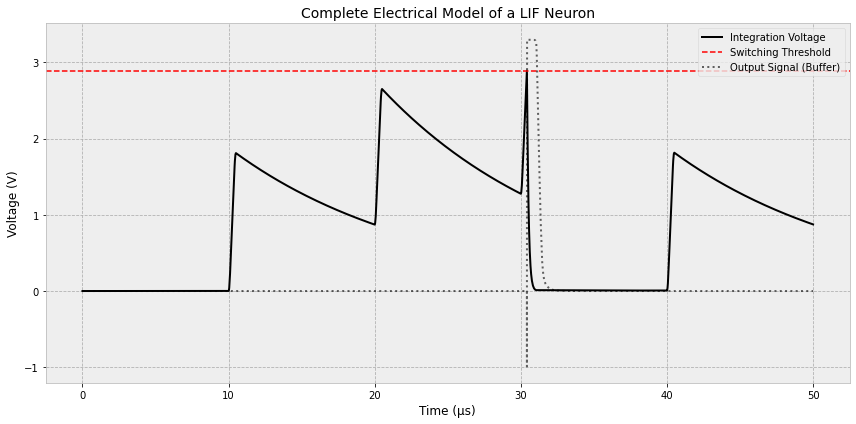

In [45]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Set a professional title
ax.set_title("Complete Electrical Model of a LIF Neuron", fontsize=14)

# Plot the integration voltage
ax.plot(time, integration, color="black", linewidth=2, label="Integration Voltage")

# Display the upper hysteresis switching threshold (e.g., 2.89 V)
ax.axhline(y=(1.45 + 1.44), color="red", linestyle="--", linewidth=1.5, label="Switching Threshold")

# Plot the buffer output signal (using a distinct dotted style for clarity)
ax.plot(time, buffer, color="black", alpha=0.6, linestyle=":", linewidth=2, label="Output Signal (Buffer)")

# Format the axes
ax.set_ylabel("Voltage (V)", fontsize=12)
ax.set_xlabel("Time (µs)", fontsize=12)

# Add legend in an optimal position
ax.legend(loc="upper right")

# Optimize layout and display
plt.tight_layout()
plt.show()

The first LIF model is finished. 

## Resumé du circuit

Le circuiot dans la première partie peut-être résumé de la manière suivante avec les différents fichiers (cf. [](#leak_integrator_fires_complet_summary_SNN)).

```{figure} ./images/leak_integrator_fires_complet_summary.svg
:name: leak_integrator_fires_complet_summary_SNN
:align: center
:width: 600px

Résumé du LIF circuit 
```